# Data Validation and Analysis

## Objective

This exploratory data analysis aims to investigate whether the generated dataset follows the assumptions, distributions, and relationships as stated in the model. The analysis also aims to extract data-driven insights to shape policy in disaster reduction and mitigation related to flooding and extreme rainfall events. The analysis includes descriptive statistics, distribution visualizations, relationship analysis, and validation of key model variables.

# Setting Up

In [3]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# reading the datasets
from google.colab import drive
drive.mount('/content/drive')

locations = pd.read_csv('/content/drive/MyDrive/Jek - Flood Risk Mapping/Data/Generated Data/locations.csv')
elevation_proxies = pd.read_csv('/content/drive/MyDrive/Jek - Flood Risk Mapping/Data/Generated Data/elevation_proxies.csv')
events = pd.read_csv('/content/drive/MyDrive/Jek - Flood Risk Mapping/Data/Generated Data/events.csv')
assets = pd.read_csv('/content/drive/MyDrive/Jek - Flood Risk Mapping/Data/Generated Data/assets.csv')
damages = pd.read_csv('/content/drive/MyDrive/Jek - Flood Risk Mapping/Data/Generated Data/damages.csv')

# preview of datasets
display(locations.head())
display(elevation_proxies.head())
display(events.head())
display(assets.head())
display(damages.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,location_id,region,lat,lon,urban_level,population,wealth_index,vegetation_index,elevation_proxy_id
0,0,Luzon,14.6155,117.9975,0.356030,2809,0.329798,0.023720,0
1,1,Mindanao,5.7046,124.2509,0.465093,759,0.322492,0.040575,1
2,2,Mindanao,6.9065,126.0599,0.615651,1207,0.329757,0.639270,2
3,3,Visayas,9.0963,123.8632,0.538283,848,0.311911,0.652906,3
4,4,Luzon,17.3406,120.5569,0.410809,4207,0.511126,0.422794,4


,elevation_proxy_id,location_id,elevation,distance_to_water,slope,flood_susceptibility
0,0,0,503.665938,751.305588,9.468826,0.585330
1,1,1,2213.055795,227.392533,19.669197,0.575342
2,2,2,2565.325172,973.793466,25.457299,0.478225
3,3,3,1939.016129,20.710684,17.864596,0.576746
4,4,4,803.768573,1908.951027,13.702482,0.460747


,event_id,location_id,rainfall_mm,flood_susceptibility,start_date,end_date,duration,season,event_region
0,0,6,294.349941,0.602959,2026-11-29,2026-12-02,3,wet,Luzon
1,0,13,294.349941,0.549515,2026-11-29,2026-12-02,3,wet,Luzon
2,0,14,294.349941,0.586466,2026-11-29,2026-12-02,3,wet,Luzon
3,0,20,294.349941,0.434447,2026-11-29,2026-12-02,3,wet,Luzon
4,0,23,294.349941,0.642245,2026-11-29,2026-12-02,3,wet,Luzon


,asset_id,location_id,asset_type,asset_subtype,asset_value
0,0,0,vehicle,motorcycle,1.437664e+05
1,1,0,residential,low,1.177424e+06
2,2,0,infrastructure,local,1.070730e+07
3,3,0,infrastructure,major,4.245548e+08
4,4,0,residential,high,9.391354e+06


,damage_id,asset_id,event_id,damage_occurs,damage_value,damage_level
0,0,110,0,0,0.000000e+00,NaN
1,1,111,0,0,0.000000e+00,NaN
2,2,112,0,1,6.629958e+05,Minor
3,3,113,0,1,3.515138e+06,Severe
4,4,114,0,0,0.000000e+00,NaN


# Dataset Structures

In [4]:
# Checking the shape and values of the datasets
print("Locations Table")
locations.info()
print(locations.shape)
print()
print("Elevation Proxies Table")
elevation_proxies.info()
print(elevation_proxies.shape)
print()
print("Events Table")
events.info()
print(events.shape)
print()
print("Assets Table")
assets.info()
print(assets.shape)
print()
print("Damage Reports Table")
damages.info()
print(damages.shape)
print()
events["event_id"].unique()

Locations Table
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         10000 non-null  int64  
 1   region              10000 non-null  object 
 2   lat                 10000 non-null  float64
 3   lon                 10000 non-null  float64
 4   urban_level         10000 non-null  float64
 5   population          10000 non-null  int64  
 6   wealth_index        10000 non-null  float64
 7   vegetation_index    10000 non-null  float64
 8   elevation_proxy_id  10000 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 703.3+ KB
(10000, 9)

Elevation Proxies Table
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   elevation_proxy_id    10

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

#### Key Observations
*   Realistic number of rows match most of what's intended during the dataset planning; 10,000 locations, one-to-one correspondence of locations and elevation proxies, reasonable derived number of assets.
*   While the events table have 220,517 rows, running value counts showed that there are 200 unique rainfall events. The explosion of rows likely came after merging events, locations, and elevation proxies.
*  The drastically large number of rows on the damages table is likely caused due to the large number of assets being hit by various rainfall events.

## Descriptive Statistics
We will explore the variables of each table including its summary statistics, distribution of variables, dispersion, etc.

### Locations

In [5]:
display(locations.describe())
print()
locations["region"].value_counts(normalize=True)

,location_id,lat,lon,urban_level,population,wealth_index,vegetation_index,elevation_proxy_id
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,4999.50000,12.043311,121.121873,0.406456,6051.773900,0.494289,0.570405,4999.50000
std,2886.89568,4.046422,2.836147,0.274574,10607.269151,0.284511,0.329435,2886.89568
min,0.00000,5.000500,116.003100,0.000000,32.000000,0.000000,0.000000,0.00000
25%,2499.75000,8.476025,118.968750,0.168338,1291.000000,0.272690,0.310711,2499.75000
50%,4999.50000,12.118500,121.001850,0.395924,2948.500000,0.439934,0.591512,4999.50000
75%,7499.25000,15.551675,123.224350,0.617980,6616.500000,0.679692,0.874945,7499.25000
max,9999.00000,18.997900,126.998100,1.000000,261729.000000,1.000000,1.000000,9999.00000


,proportion
region,
Luzon,0.5076
Mindanao,0.2887
Visayas,0.2037


#### Key Observations
* A latitude range of [5, 19] and longitude range of [116, 127] matches real Philippine coordinates.
* The mean and median of the urbanization level being almost equal suggest symmetry in the distribution.
* The average, minimum, and maximum population of locations matches realistic Philippine conditions.
* The values on wealth and vegetation index lie within the intended range.
* The proportion of locations lying on the three specified regions aligned with the intended probability (50% on Luzon, 30% on Mindanao, and 20% in Visayas).

### Elevation Proxies

In [6]:
display(elevation_proxies.describe())

,elevation_proxy_id,location_id,elevation,distance_to_water,slope,flood_susceptibility
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,4999.50000,1423.837300,986.854416,19.433526,0.545340
std,2886.89568,2886.89568,903.016555,989.321682,9.174142,0.087108
min,0.00000,0.00000,0.000000,0.002276,0.000000,0.069543
25%,2499.75000,2499.75000,502.224401,283.293577,12.874473,0.500057
50%,4999.50000,4999.50000,1737.538094,681.386249,19.171178,0.556897
75%,7499.25000,7499.25000,2156.356213,1358.233192,25.101327,0.604833
max,9999.00000,9999.00000,2938.755805,9653.499133,45.000000,0.755596


#### Key Observations
* The elevation and distance to water data distribution aligns with realism.
* Slope matches intended range and contains reasonably realistic values.
* An almost equal mean and median of flood susceptibility suggests symmetry with the distribution. Moreover, a mean of 54% and a 75th percentile of 60% suggests that most locations are at low to average susceptibility, which is realistic.

### Events

In [7]:
display(events.describe())
print()
print(events["event_region"].value_counts(normalize=True))
print()
print(events["season"].value_counts(normalize=True))

,event_id,location_id,rainfall_mm,flood_susceptibility,duration
count,220517.000000,220517.000000,220517.000000,220517.000000,220517.000000
mean,102.267344,4997.254842,195.577626,0.552044,2.532657
std,57.060235,2885.446211,108.348988,0.087007,1.145289
min,0.000000,0.000000,56.455578,0.069543,1.000000
25%,54.000000,2499.000000,101.825099,0.507040,1.000000
50%,101.000000,4994.000000,159.016930,0.563310,3.000000
75%,151.000000,7494.000000,275.480946,0.612439,4.000000
max,199.000000,9999.000000,518.333245,0.755596,4.000000



event_region
Luzon       0.577266
Mindanao    0.239256
Visayas     0.183478
Name: proportion, dtype: float64

season
wet    0.510364
dry    0.489636
Name: proportion, dtype: float64


#### Key Observations
* High values on precipitation in mm are due to the fact that the precipitation is accumulated over the total duration of the event, the average daily precipitation in a specific event may be computed by dividing the precipitation by the duration.
* An almost equal mean and median of flood susceptibility suggests symmetry with the distribution. Moreover, a mean of 54% and a 75th percentile of 60% suggests that most locations are at low to average susceptibility, which is realistic.
* Duration is reasonable with rain spanning 1 to 4 days. However, more realism may be achieved with some rainfall events being experienced in the Philippines spanning well over four days.
* The distribution of events over regions match with the intended probabilities with minimal deviations.
* While the occurence of rain over the wet season is a bit larger over the dry season, more realism may be achieved by having more rain occur during the wet season in contrast to the dry season.

### Assets

In [8]:
display(assets.describe())
print()
print(assets["asset_type"].value_counts(normalize=True))
print()
assets.groupby("asset_type")["asset_subtype"].value_counts(normalize=True)

,asset_id,location_id,asset_value
count,200074.000000,200074.000000,2.000740e+05
mean,100036.500000,5005.415736,4.140147e+07
std,57756.533216,2891.334392,1.561359e+08
min,0.000000,0.000000,6.770975e+04
25%,50018.250000,2496.250000,1.287072e+06
50%,100036.500000,5004.000000,4.408954e+06
75%,150054.750000,7518.000000,1.065280e+07
max,200073.000000,9999.000000,2.070104e+09



asset_type
residential       0.499425
infrastructure    0.201296
commercial        0.198871
vehicle           0.100408
Name: proportion, dtype: float64



asset_type      asset_subtype
commercial      small            0.700520
                medium           0.249868
                large            0.049612
infrastructure  local            0.748200
                major            0.202041
                critical         0.049759
residential     low              0.499790
                mid              0.350854
                high             0.149356
vehicle         motorcycle       0.596894
                car              0.302006
                PUV              0.101100
Name: proportion, dtype: float64

#### Key Observations

* Reasonable asset values given the current economic state of the Philippines (minimum of 60k, median of 4 mil, max of 2 bil).
* Distribution of main asset types match the intended plan with minimal to no deviations.
* Similar to the main asset types, the distribution of subtypes in each asset type also matches the intended plan with minimal deviations.

In [9]:
display(damages.describe())
print()
damages["damage_level"] = damages["damage_level"].fillna("None")
damages["damage_level"].value_counts(normalize=True)

,damage_id,asset_id,event_id,damage_occurs,damage_value
count,4.411263e+06,4.411263e+06,4.411263e+06,4.411263e+06,4.411263e+06
mean,2.205631e+06,9.994242e+04,1.023038e+02,2.263669e-01,4.417840e+06
std,1.273422e+06,5.772734e+04,5.705741e+01,4.184794e-01,4.113548e+07
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.102816e+06,4.994800e+04,5.400000e+01,0.000000e+00,0.000000e+00
50%,2.205631e+06,9.980600e+04,1.010000e+02,0.000000e+00,0.000000e+00
75%,3.308446e+06,1.498970e+05,1.510000e+02,0.000000e+00,0.000000e+00
max,4.411262e+06,2.000730e+05,1.990000e+02,1.000000e+00,4.863079e+09


,proportion
damage_level,
None,0.773676
Severe,0.076950
Minor,0.074687
Moderate,0.074687


#### Key Observations
* A damage value of 0 from the minimum to the 75th percentile may be caused by the fact that only a small proportion of assets affected by the events were considered to be damaged.
* Only 23% of assets being damaged is reasonable, however the distribution of damage level along damaged assets (severe, minor, moderate) may be added more realism as the distribution among these is two uniform.

# Distributions and Relationships

Here, we check if the distributions of the values and the relationships align with what was intended with the model. I will use a lot of visualizations and charts.

## Locations

### Population Distribution

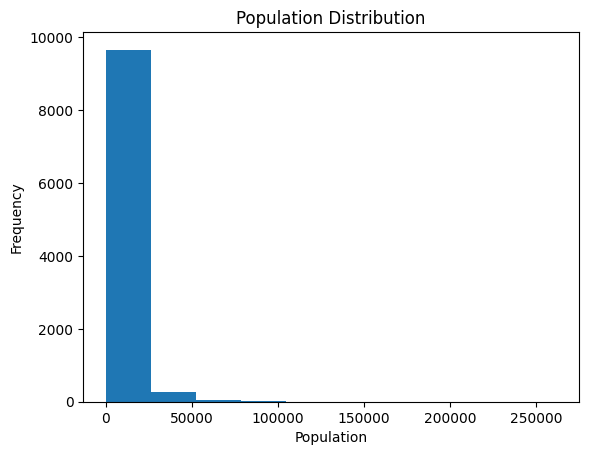

In [10]:
plt.hist(locations["population"])
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.title("Population Distribution")
plt.show()

Population is heavily right tailed; a very large majority of locations contain a population of below 50,000 people while there are a very few that reach thresholds such as 100,000 up to 250,000.

### Population and Wealth Index

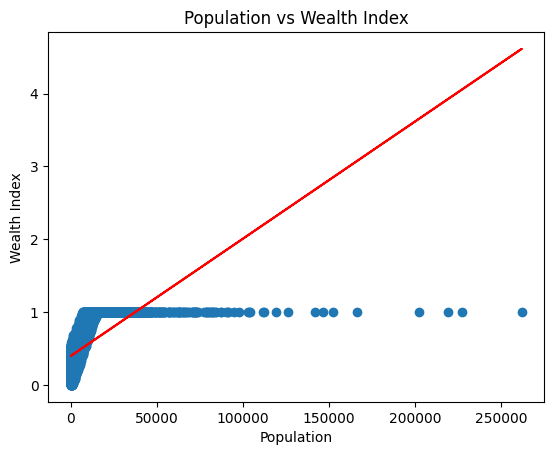


0.6005270231138616


In [11]:
x = locations["population"]
y = locations["wealth_index"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Population")
plt.ylabel("Wealth Index")
plt.title("Population vs Wealth Index")
plt.show()
print()
print(locations["population"].corr(locations["wealth_index"]))

A correlation coefficient of 0.60 suggests a strong positive relationship between population and wealth index; more populated locations generate/require higher income. While the scatterplot looks off, this is due to the skewness brought by locations with drastically huge populations relative to others.

### Urbanization Level and Wealth Index

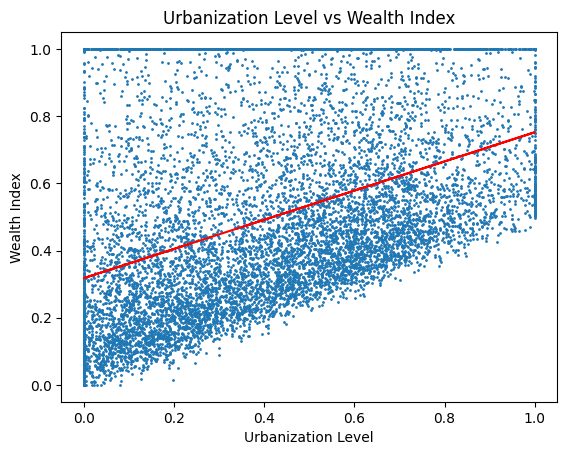


0.4189045213693998


In [12]:
x = locations["urban_level"]
y = locations["wealth_index"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y, s=1)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Urbanization Level")
plt.ylabel("Wealth Index")
plt.title("Urbanization Level vs Wealth Index")
plt.show()
print()
print(locations["urban_level"].corr(locations["wealth_index"]))

Relationship is moderately positive, this aligns with the fact that while we expect more urbanized locations to yield higher incomes, this is not always the case, the same can be said for less urbanized locations yielding lower incomes. Moreover, the chart captures the abundance of wealthy locations (wealth_index=1) over all urbanization levels.

### Vegetation Index and Urban Level

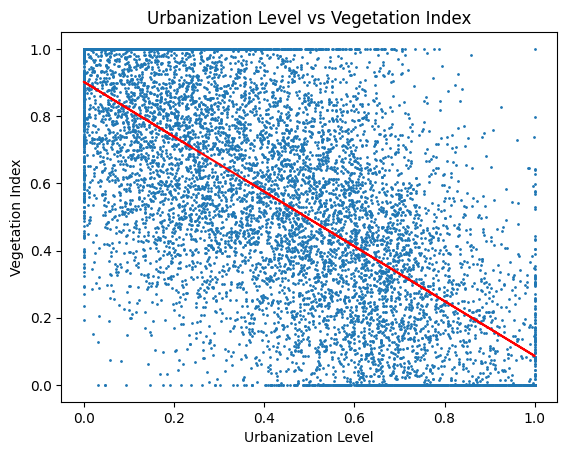


-0.6799638291511618


In [13]:
x = locations["urban_level"]
y = locations["vegetation_index"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y, s=1)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Urbanization Level")
plt.ylabel("Vegetation Index")
plt.title("Urbanization Level vs Vegetation Index")
plt.show()
print()
print(locations["urban_level"].corr(locations["vegetation_index"]))

The data suggests a strong negative correlation with urbanization level and vegetation index, this aligns with the notion that lesser urbanized areas contain more green and vegetized land.

## Elevation Proxies

region
Luzon        656.229712
Mindanao    2329.980380
Visayas     2052.379788
Name: elevation, dtype: float64
region
Luzon        515.398966
Mindanao    2342.908743
Visayas     2056.244282
Name: elevation, dtype: float64

                 mean       median         std          min          max
region                                                                  
Luzon      656.229712   515.398966  559.980140     0.000000  2240.630067
Mindanao  2329.980380  2342.908743  349.021108  1378.817245  2938.755805
Visayas   2052.379788  2056.244282  147.785757  1651.722914  2337.466333


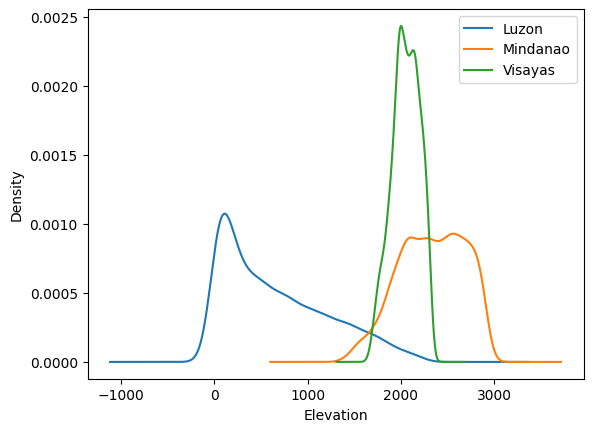

In [14]:
df = elevation_proxies.merge(locations, on="location_id", how="left")
print(df.groupby("region")["elevation"].mean())
print(df.groupby("region")["elevation"].median())
print()
print(df.groupby("region")["elevation"].agg(["mean", "median", "std", "min", "max"]))

for r in df["region"].unique():
    subset = df[df["region"] == r]
    subset["elevation"].plot(kind="kde", label=r)

plt.legend()
plt.xlabel("Elevation")
plt.show()

The data suggests that Visayas and Mindanao has higher average elevations. While realistically speaking, Luzon's average should not be this low, this may be a product of noise, computational error, and other possible factors.

### Water Distance Distribution

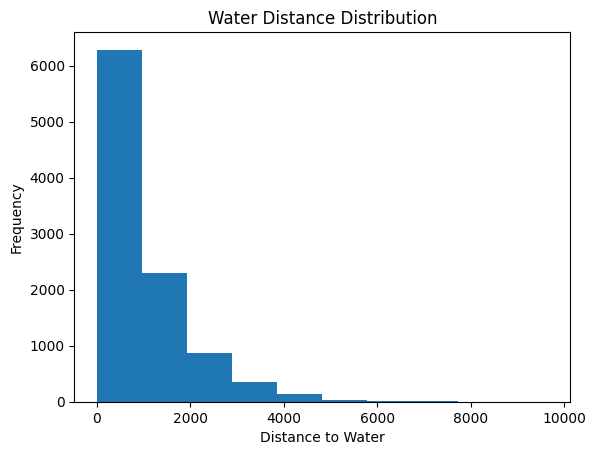

In [15]:
plt.hist(elevation_proxies["distance_to_water"])
plt.xlabel("Distance to Water")
plt.ylabel("Frequency")
plt.title("Water Distance Distribution")
plt.show()

Water distance followed an exponential distribution as intended in the data plan.

### Slope Distribution

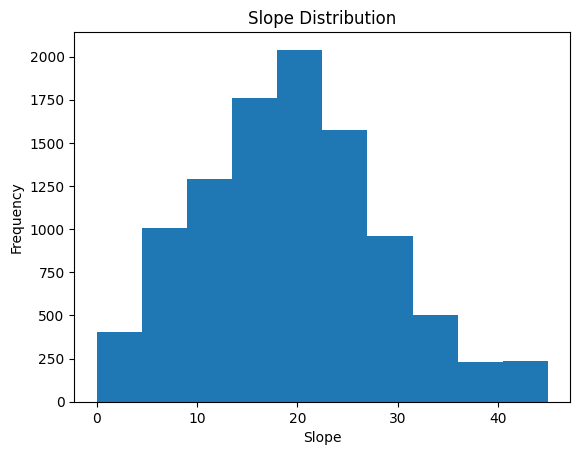

In [16]:
plt.hist(elevation_proxies["slope"])
plt.xlabel("Slope")
plt.ylabel("Frequency")
plt.title("Slope Distribution")
plt.show()

The slope distribution appears normal with a mean around 20. Values fit the intended range of [0, 45]. Data seems normal, nothing suspicious.

### Slope and Elevation

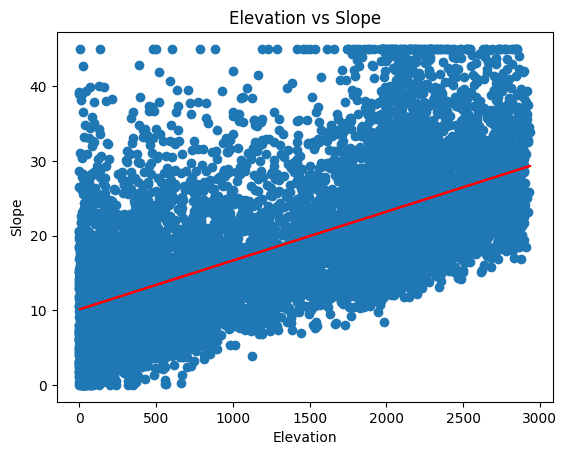


0.643495639521327


In [17]:
x = elevation_proxies["elevation"]
y = elevation_proxies["slope"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Elevation")
plt.ylabel("Slope")
plt.title("Elevation vs Slope")
plt.show()
print()
print(elevation_proxies["elevation"].corr(elevation_proxies["slope"]))

The scatterplot and correlation coefficient shows a strong positive relation between elevation and slope, aligns with the concept of slope being directly proportional to elevation.

### Flood Susceptibility Distribution

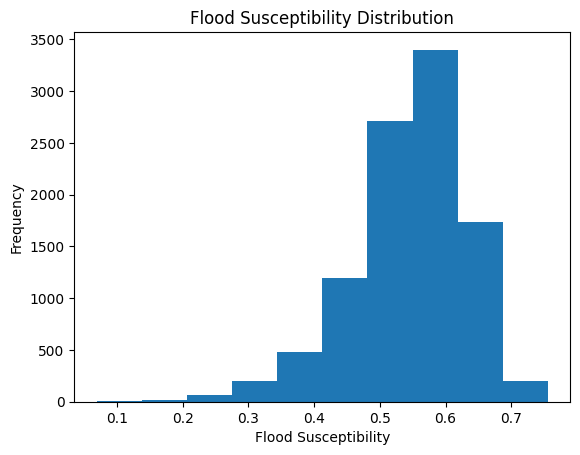

In [18]:
plt.hist(elevation_proxies["flood_susceptibility"])
plt.xlabel("Flood Susceptibility")
plt.ylabel("Frequency")
plt.title("Flood Susceptibility Distribution")
plt.show()

The distribution suggests that flood susceptibility among locations are centered at around 50%-60%, suggesting that a majority of the locations are at around low to mild susceptibility, with some locations reaching up to 70%. The absence of flood susceptibilities reaching 90%-100% is realistic as we do not expect a location to be fully susceptible to flooding.

### Flood Susceptibility and Elevation

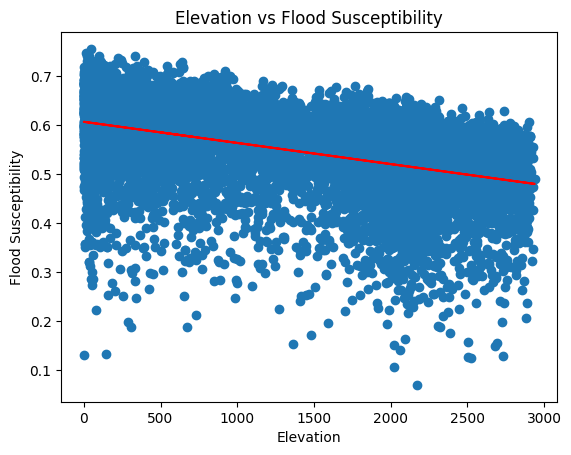


-0.4473705822549355


In [19]:
x = elevation_proxies["elevation"]
y = elevation_proxies["flood_susceptibility"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Elevation")
plt.ylabel("Flood Susceptibility")
plt.title("Elevation vs Flood Susceptibility")
plt.show()
print()
print(elevation_proxies["elevation"].corr(elevation_proxies["flood_susceptibility"]))

The scatterplot and correlation coefficient suggests a moderately negative relationship between elevation and flood susceptibility. This is ideal as flood susceptibility decreases with higher elevations.

### Flood Susceptibility and Slope

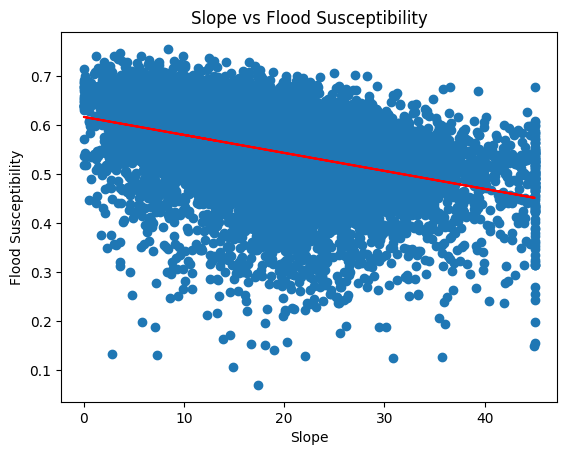


-0.38671467636703394


In [20]:
x = elevation_proxies["slope"]
y = elevation_proxies["flood_susceptibility"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Slope")
plt.ylabel("Flood Susceptibility")
plt.title("Slope vs Flood Susceptibility")
plt.show()
print()
print(elevation_proxies["slope"].corr(elevation_proxies["flood_susceptibility"]))

The data suggests a weak negative correlation between slope and flood susceptibility, which makes sense as although we expect flood susceptibility to lessen with lower slopes, that is not always the case. Slope is a valid but weak predictor of flood susceptibility.

### Flood Susceptibility and Water Distance

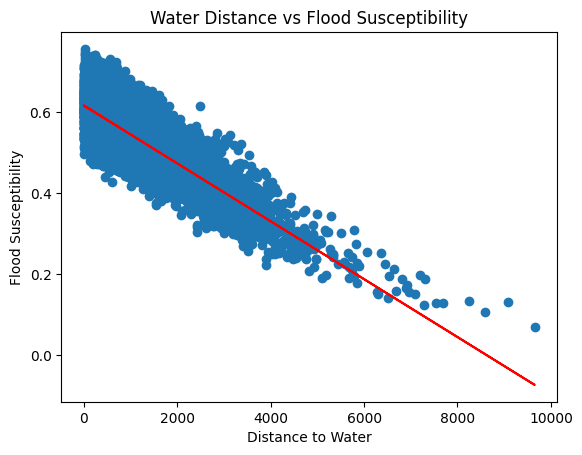


-0.8120704779621006


In [21]:
x = elevation_proxies["distance_to_water"]
y = elevation_proxies["flood_susceptibility"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Distance to Water")
plt.ylabel("Flood Susceptibility")
plt.title("Water Distance vs Flood Susceptibility")
plt.show()
print()
print(elevation_proxies["distance_to_water"].corr(elevation_proxies["flood_susceptibility"]))

The plot and correlation coefficient shows a strong negative correlation between flood susceptibility. This shows that water distance is a good predictor of flood susceptibility although not deterministic. This makes sense as locations that are nearer to bodies of water such as lakes, beaches, or coasts are more prone to flooding due to rising water levels.

## Rainfall Events

### Average Rainfall Intensities Distribution per Region

region
Luzon       195.280035
Mindanao    195.612062
Visayas     196.467651
Name: rainfall_mm, dtype: float64
region
Luzon       159.01693
Mindanao    159.01693
Visayas     159.01693
Name: rainfall_mm, dtype: float64

                mean     median         std        min         max
region                                                            
Luzon     195.280035  159.01693  108.044812  56.455578  518.333245
Mindanao  195.612062  159.01693  108.537754  56.455578  518.333245
Visayas   196.467651  159.01693  109.089779  56.455578  518.333245


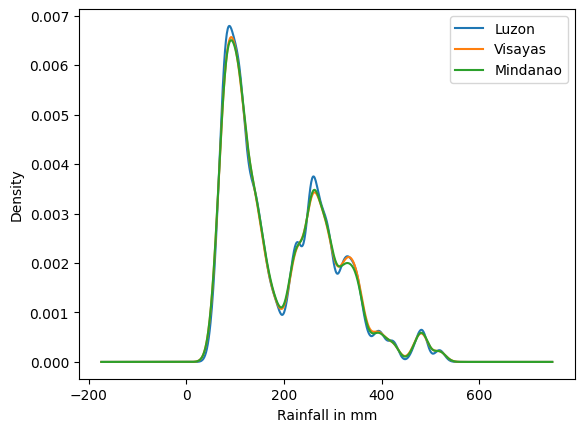

In [22]:
df = events.merge(locations, on="location_id", how="left")
print(df.groupby("region")["rainfall_mm"].mean())
print(df.groupby("region")["rainfall_mm"].median())
print()
print(df.groupby("region")["rainfall_mm"].agg(["mean", "median", "std", "min", "max"]))

for r in df["region"].unique():
    subset = df[df["region"] == r]
    subset["rainfall_mm"].plot(kind="kde", label=r)

plt.legend()
plt.xlabel("Rainfall in mm")
plt.show()

While we intended to have the regions vary in base rainfall intensity, the generated data shows that on average, the rainfall intensities of the regions align almost perfectly each other, possibly due to noise or other computational factors.

### Temporal Date Checking

In [23]:
events['start_date'] = pd.to_datetime(events['start_date'])
events['expected_end'] = events['start_date'] + pd.to_timedelta(events['duration'], unit='D')
events['matches'] = events['end_date'] == events['expected_end']
mismatches = events[~events['matches']]
print(mismatches)

Empty DataFrame
Columns: [event_id, location_id, rainfall_mm, flood_susceptibility, start_date, end_date, duration, season, event_region, expected_end, matches]
Index: []


Above, we checked if there are any mismatches to the formula
end_date = start_date + duration
Fortunately, we saw none.

## Assets

### Asset Value and Urbanization Level

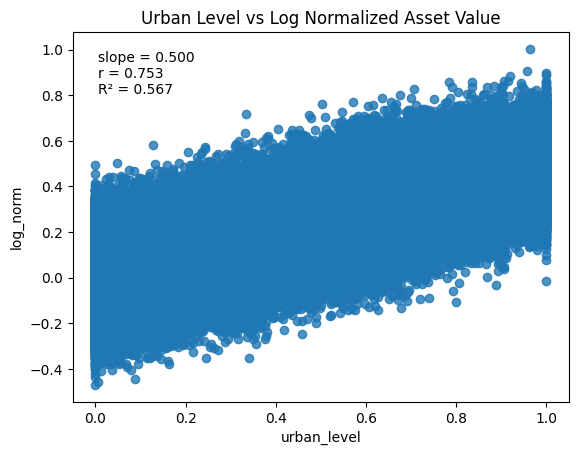

In [24]:
from scipy.stats import linregress

df = assets.merge(locations, on="location_id", how="left")

BASE_VALUES = {
    ("residential", "low"): 1000000,
    ("residential", "mid"): 3000000,
    ("residential", "high"): 8000000,
    ("commercial", "small"): 5000000,
    ("commercial", "medium"): 50000000,
    ("commercial", "large"): 500000000,
    ("infrastructure", "local"): 10000000,
    ("infrastructure", "major"): 300000000,
    ("infrastructure", "critical"): 1000000000,
    ("vehicle", "motorcycle"): 100000,
    ("vehicle", "car"): 800000,
    ("vehicle", "PUV"): 500000
}

df["base"] = list(zip(df["asset_type"], df["asset_subtype"]))
df["base"] = df["base"].map(BASE_VALUES)

df["norm_value"] = df["asset_value"] / df["base"]
df["log_norm"] = np.log(df["norm_value"])

sns.regplot(x="urban_level", y="log_norm", data=df)

res = linregress(df["urban_level"], df["log_norm"])

plt.text(
    0.05, 0.95,
    f"slope = {res.slope:.3f}\nr = {res.rvalue:.3f}\nR² = {res.rvalue**2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.title("Urban Level vs Log Normalized Asset Value")
plt.show()

Above is a graph comparing urban level and normalized asset values (actual asset value/base value). A positive correlation is visible through the graph and a correlation coefficient of 0.753 shows strong correlation, hinting that urbanization level has a directly proportional impact to asset values, which makes sense since assets are pricier in more urbanized areas.

## Damages

### Damage Level and Flood Susceptibility

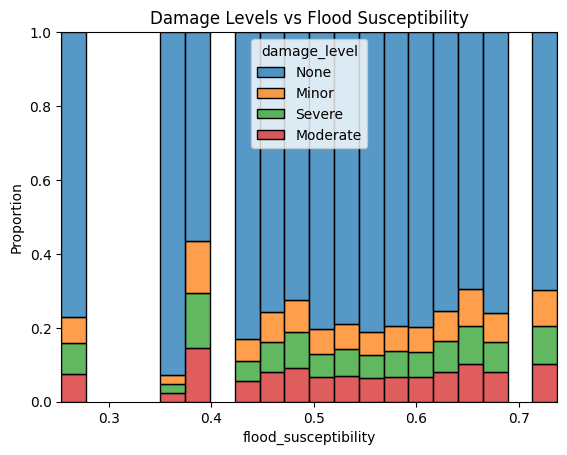

In [25]:
df = damages[["event_id", "damage_level"]].merge(
    events[["event_id", "location_id", "flood_susceptibility"]].drop_duplicates("event_id"),
    on="event_id",
    how="left",
    validate="many_to_one"
)

sns.histplot(
    data=df,
    x="flood_susceptibility",
    hue="damage_level",
    multiple="fill",
    bins=20
)

plt.ylabel("Proportion")
plt.title("Damage Levels vs Flood Susceptibility")
plt.show()

  The proportion of damages seem to fluctuate in terms of flood susceptibility, aside from the 0.35-0.4 range where there are higher damages, but it may probably just be noise.

### Damage Level and Urban Level

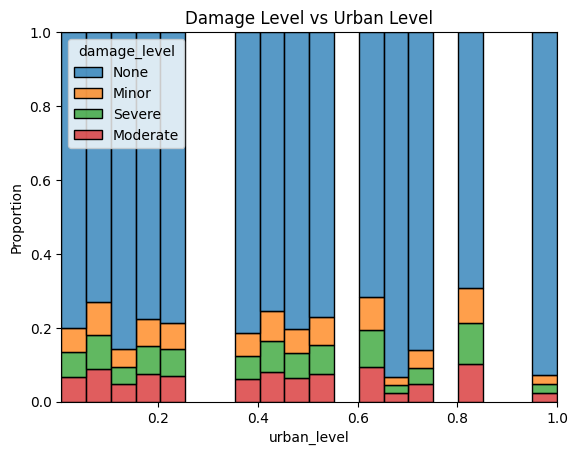

In [26]:
df = df.merge(
locations[["location_id", "urban_level"]].drop_duplicates("urban_level"),
on="location_id",
how="left",
validate="many_to_one"
)

f = df.copy()

if "urban_level_y" in df.columns:
    df["urban_level"] = df["urban_level_y"]
elif "urban_level_x" in df.columns:
    df["urban_level"] = df["urban_level_x"]

df = df.drop(columns=[c for c in ["urban_level_x", "urban_level_y"] if c in df.columns])

df = df.dropna(subset=["urban_level", "damage_level"])

sns.histplot(
    data=df,

    x="urban_level",
    hue="damage_level",
    multiple="fill",
    bins=20
)

plt.ylabel("Proportion")
plt.title("Damage Level vs Urban Level")
plt.show()

The chart above shows that some higher urban areas (particularly in the graph, those with an index of 0.7 and 1) see fewer damage occurences. This may be potentially due to better infrastructure, flood control systems, or mitigation capacity. However, this should be interpreted as an association rather than a causal effect, since other confounding factors (such as event intensity or location-specific characteristics) may also influence the observed pattern. It is also worth to note that the fluctuations we see may be due to noise, particularly in the increase of damages and severity in 0.1 and 0.8.

### Damage Level and Vegetation

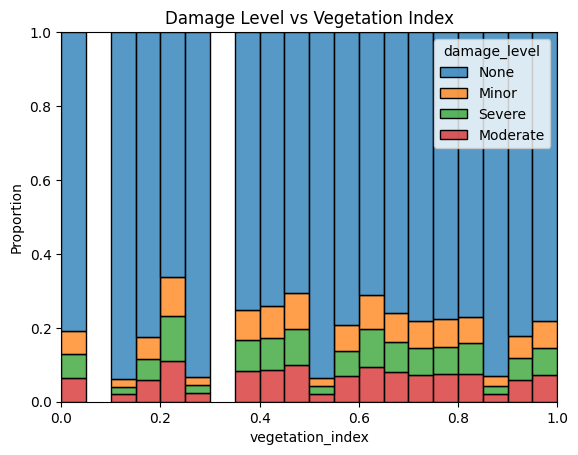

In [27]:
df = damages[["event_id", "damage_level"]].merge(
    events[["event_id", "location_id"]].drop_duplicates("event_id"),
    on="event_id",
    how="left",
    validate="many_to_one"
)

df = df.merge(
    locations[["location_id", "vegetation_index"]].drop_duplicates("location_id"),
    on="location_id",
    how="left",
    validate="many_to_one"
)

sns.histplot(
    data=df,
    x="vegetation_index",
    hue="damage_level",
    multiple="fill",
    bins=20
)

plt.ylabel("Proportion")
plt.title("Damage Level vs Vegetation Index")
plt.show()

The relationship between vegetation index and damage level does not exhibit a clear monotonic trend. Instead, the proportion of damage categories fluctuates across the range of vegetation values, with intermittent increases and decreases rather than a consistent directional pattern. This suggests that vegetation index alone does not provide a strong or stable explanation of damage severity in this dataset.

### Damage Level and Elevation Proxies

In [28]:
df = damages[["event_id", "damage_level", "damage_value"]].merge(
    events[["event_id", "location_id", "rainfall_mm"]].drop_duplicates("event_id"),
    on="event_id",
    how="left",
    validate="many_to_one"
)

df = df.merge(
    elevation_proxies[[
        "location_id",
        "elevation",
        "distance_to_water",
        "slope",
        "flood_susceptibility"
    ]].drop_duplicates("location_id"),
    on="location_id",
    how="left",
    validate="many_to_one"
)

df = df.dropna(subset=["damage_level"])

def plot_damage_by_variable(df, var, bins=10):
    df["bin"] = pd.qcut(df[var], bins, duplicates="drop")

    plot = df.groupby("bin")["damage_level"] \
             .value_counts(normalize=True) \
             .unstack()

    plot.plot(kind="bar", stacked=True, figsize=(10,5))

    plt.title(f"Damage Level vs {var}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.show()

### Damage Level and Elevation

/tmp/ipykernel_10323/393359989.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot = df.groupby("bin")["damage_level"] \


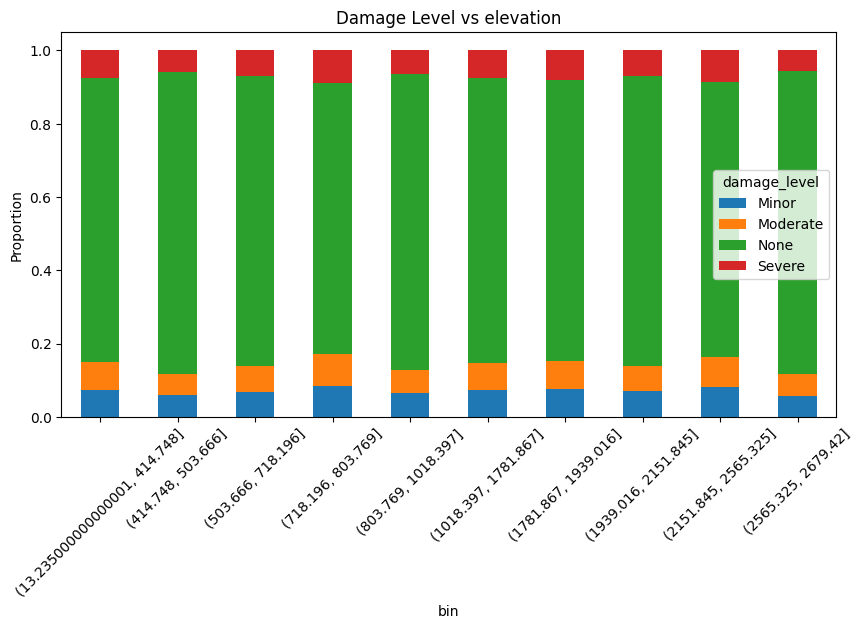

In [29]:
plot_damage_by_variable(df, "elevation")

### Damage Level and Slope

/tmp/ipykernel_10323/393359989.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot = df.groupby("bin")["damage_level"] \


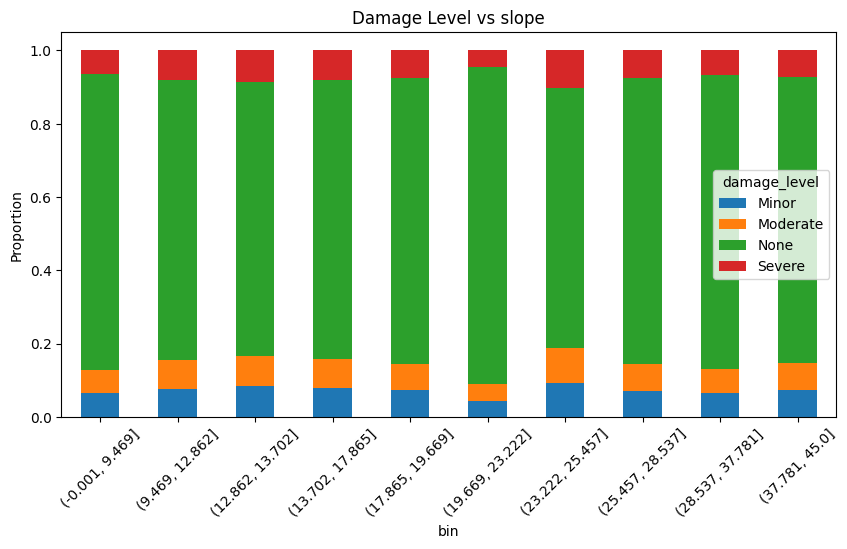

In [30]:
plot_damage_by_variable(df, "slope")

### Damage Level and Distance to Water

/tmp/ipykernel_10323/393359989.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot = df.groupby("bin")["damage_level"] \


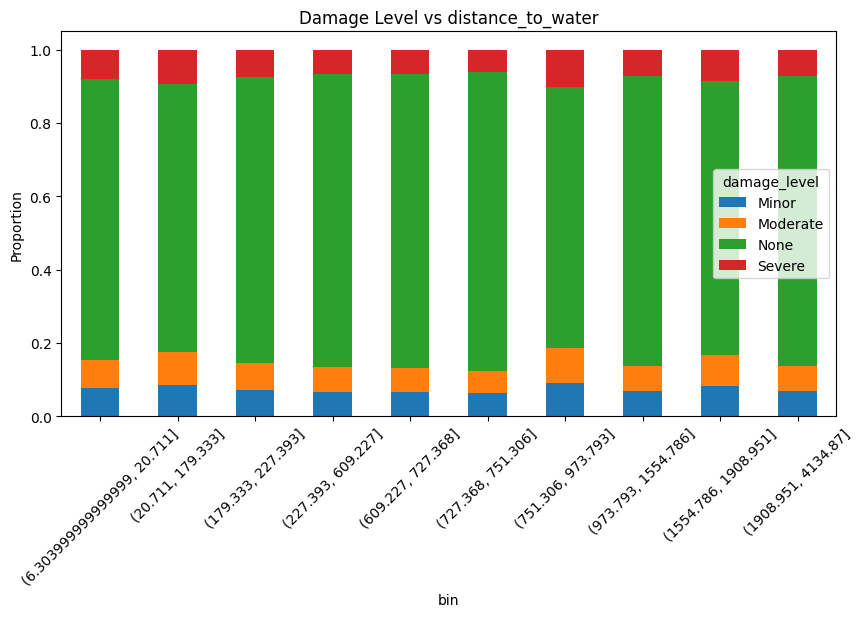

In [31]:
plot_damage_by_variable(df, "distance_to_water")

Across elevation, slope, and distance to water, the distribution of damage levels remains relatively stable, with no strong monotonic or stratified pattern observed. This suggests that topographic variables contribute weakly, if at all, to the variation in damage severity within the current model, and that outcomes are primarily driven by event-level stochasticity and hazard intensity rather than spatial heterogeneity.

While this may seem strange, because you may expect lower elevations, lower slopes, or locations closer to water to receive more damage when flooding comes, it is worth noting that other factors may come to place such as preparedness, disaster mitigation, and even flood control (which is a latent variable I omitted).

For example, if the area has low elevation and is closer to water, we expect the governing unit to be more proactive when it comes to disaster preparedness and control.

With that, the model became more nuanced. It accepts interaction and noise interference, effects of latent variables, and captures the interaction of different variables.

In [32]:
df["damage_value_log"] = np.log1p(df["damage_value"])

print(df["damage_value_log"].corr(df["elevation"]))
print(df["damage_value_log"].corr(df["slope"]))
print(df["damage_value_log"].corr(df["distance_to_water"]))

0.028582701518470737
-0.010134746512115007
0.01409806915598431


Since damage level is derived from damage value, after checking the correlation of damage level with elevation, slope, and distance to water, the three variables are not a direct predictor to damage level which explains the uniformity/lack of patterns in the graph.

### Damage Level and Asset Values

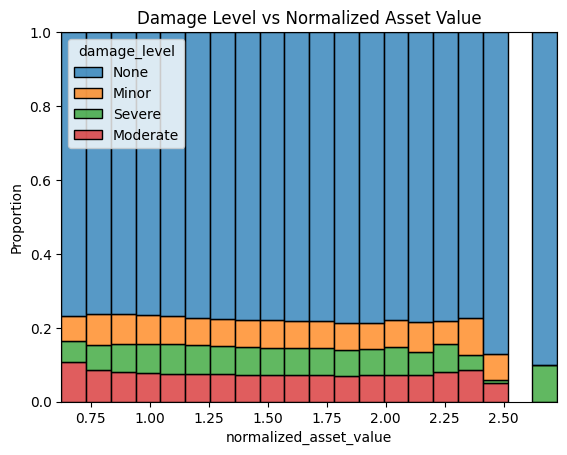

In [33]:
df = damages[["asset_id", "damage_level"]].merge(
    assets[["asset_id", "asset_type", "asset_subtype", "asset_value"]],
    on="asset_id",
    how="left"
)

BASE_VALUES = {
    ("residential", "low"): 1000000,
    ("residential", "mid"): 3000000,
    ("residential", "high"): 8000000,
    ("commercial", "small"): 5000000,
    ("commercial", "medium"): 50000000,
    ("commercial", "large"): 500000000,
    ("infrastructure", "local"): 10000000,
    ("infrastructure", "major"): 300000000,
    ("infrastructure", "critical"): 1000000000,
    ("vehicle", "motorcycle"): 100000,
    ("vehicle", "car"): 800000,
    ("vehicle", "PUV"): 500000
}

df["base_value"] = list(zip(df["asset_type"], df["asset_subtype"]))
df["base_value"] = df["base_value"].map(BASE_VALUES)

df["normalized_asset_value"] = df["asset_value"] / df["base_value"]

df = df.dropna(subset=["normalized_asset_value", "damage_level"])

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="normalized_asset_value",
    hue="damage_level",
    multiple="fill",
    bins=20
)

plt.ylabel("Proportion")
plt.title("Damage Level vs Normalized Asset Value")
plt.show()

A very very minor increase in severity as asset value increases. It is particularly noticeable that with the rightmost tail where highest asset values lie, only severe damages were observed when there are damages, which makes sense since higher valued assets result to greater losses.

In [34]:
damages.head()

,damage_id,asset_id,event_id,damage_occurs,damage_value,damage_level
0,0,110,0,0,0.000000e+00,None
1,1,111,0,0,0.000000e+00,None
2,2,112,0,1,6.629958e+05,Minor
3,3,113,0,1,3.515138e+06,Severe
4,4,114,0,0,0.000000e+00,None


Now, we already analyzed what proportion of all affected assets were damaged, now we will remove undamaged assets from the damages table so we can better shift our focus.

In [35]:
damages_clean = damages[damages["damage_occurs"] != 0]
damages.head()

,damage_id,asset_id,event_id,damage_occurs,damage_value,damage_level
0,0,110,0,0,0.000000e+00,None
1,1,111,0,0,0.000000e+00,None
2,2,112,0,1,6.629958e+05,Minor
3,3,113,0,1,3.515138e+06,Severe
4,4,114,0,0,0.000000e+00,None


### Damage Value and Asset Value

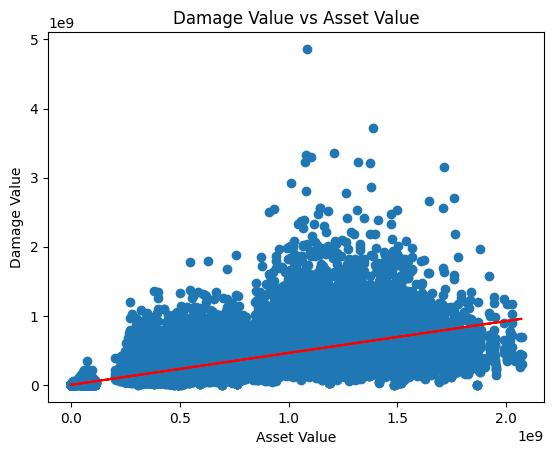


0.8473189725528928


In [36]:
damages_assets = damages_clean.merge(assets, on="asset_id", how="left")

x = damages_assets["asset_value"]
y = damages_assets["damage_value"]
m, b = np.polyfit(x, y, 1)
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")
plt.xlabel("Asset Value")
plt.ylabel("Damage Value")
plt.title("Damage Value vs Asset Value")
plt.show()
print()
print(damages_assets["asset_value"].corr(damages_assets["damage_value"]))

A correlation coefficient of 0.847 shows that asset value is a good predictor of damage value as higher value assets lead to greater losses.

### Damage Value and Flood Susceptibility

Correlation (flood vs damage ratio): 0.013230956210153143
Slope: 0.04649706906890248


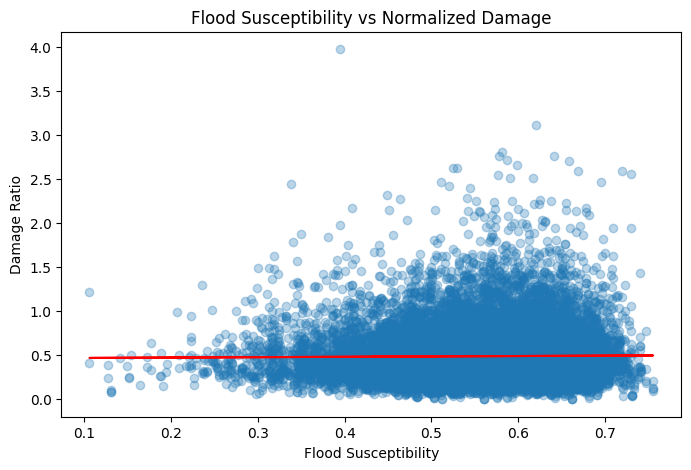

In [37]:
elev_small = elevation_proxies[["location_id", "flood_susceptibility"]].drop_duplicates("location_id")

assets_small = assets[["asset_id", "location_id", "asset_value"]].copy()

assets_loc = assets_small.merge(
    elev_small,
    on="location_id",
    how="left",
    validate="many_to_one"
)

damages_small = damages_clean[["asset_id", "damage_value"]].copy()

df = damages_small.merge(
    assets_loc,
    on="asset_id",
    how="left",
    validate="many_to_one"
)

df["damage_ratio"] = df["damage_value"] / df["asset_value"]

df = df.dropna(subset=["flood_susceptibility", "damage_ratio"])

x = df["flood_susceptibility"]
y = df["damage_ratio"]

corr = x.corr(y)
m, b = np.polyfit(x, y, 1)

print("Correlation (flood vs damage ratio):", corr)
print("Slope:", m)

plot_df = df.sample(min(len(df), 20000), random_state=42)

x_plot = plot_df["flood_susceptibility"]
y_plot = plot_df["damage_ratio"]

m_plot, b_plot = np.polyfit(x_plot, y_plot, 1)

plt.figure(figsize=(8,5))
plt.scatter(x_plot, y_plot, alpha=0.3)
plt.plot(x_plot, m_plot * x_plot + b_plot, color="red")

plt.xlabel("Flood Susceptibility")
plt.ylabel("Damage Ratio")
plt.title("Flood Susceptibility vs Normalized Damage")

plt.show()

Flood susceptibility exhibits only a weak relationship with normalized damage (correlation ≈ 0.01), suggesting limited explanatory power when considered independently. As a location-level and time-invariant variable, flood susceptibility represents background environmental risk rather than realized hazard. Its effect is likely diluted by variation across events and assets, indicating that it does not strongly influence damage outcomes on its own within the simulation.

Correlation (rainfall vs damage ratio): 0.17104705138175932


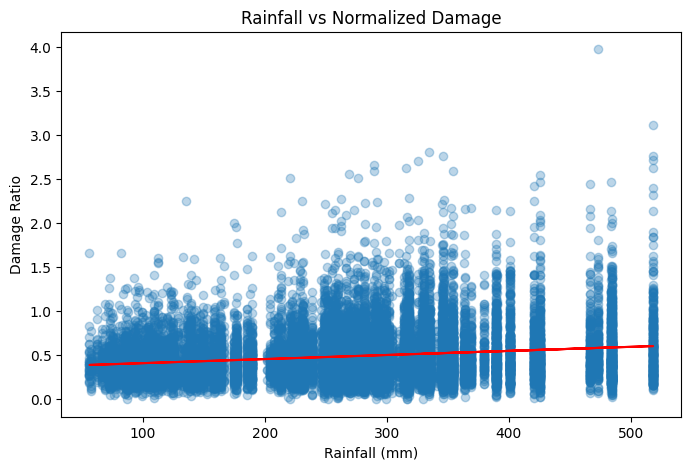

In [38]:
events_small = events[["event_id", "rainfall_mm"]].drop_duplicates("event_id")

df = damages_clean.merge(
    events_small,
    on="event_id",
    how="left",
    validate="many_to_one"
)

df = df.merge(
    assets_small,
    on="asset_id",
    how="left",
    validate="many_to_one"
)

df["damage_ratio"] = df["damage_value"] / df["asset_value"]

corr_ratio = df["rainfall_mm"].corr(df["damage_ratio"])
print("Correlation (rainfall vs damage ratio):", corr_ratio)\

plot_df = df.sample(min(len(df), 20000), random_state=42)

x = plot_df["rainfall_mm"]
y = plot_df["damage_ratio"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.3)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Rainfall (mm)")
plt.ylabel("Damage Ratio")
plt.title("Rainfall vs Normalized Damage")

plt.show()

Rainfall intensity shows a moderate positive relationship with normalized damage (correlation ≈ 0.17), indicating that higher rainfall is associated with greater proportional losses. This suggests that rainfall acts as a meaningful driver of damage severity in the simulation. As an event-level variable that varies across occurrences, rainfall aligns closely with when damage is realized, allowing it to capture variation in loss outcomes more effectively than static factors.

# Overall System Observations (Model-Level Summary)

* The dataset exhibits internally consistent relationships between geographic, environmental, and socio-economic variables (e.g., elevation, distance to water, vegetation, wealth).
* Flood susceptibility behaves directionally as expected: higher near water bodies, lower at higher elevations and steeper slopes,
influenced by vegetation and urbanization.
* Regional variation (Luzon, Visayas, Mindanao) introduces realistic heterogeneity rather than uniform patterns.
* The system reflects multi-factor dependency, not single-variable determinism—this is a strong sign of a well-structured data-generating process.
* Continuous variables (e.g., elevation, rainfall proxies, indices) appear to follow reasonable distributions (non-uniform, slightly skewed, realistic spread).
* There is evidence of interaction effects, especially urbanization and flood risk, and vegetation and susceptibility.
* The dataset avoids being “too clean”—there is natural variance and overlap, which is good for downstream modeling realism.

# Model Validation Conclusion

* The synthetic data generally aligns with the assumed structural relationships defined in the model.
* Observed correlations and patterns are directionally consistent with domain expectations (environmental science + disaster risk logic).
* There are no obvious signs of broken relationships, illogical trends, or unrealistic distributions.
* However, some relationships may appear slightly smoother or more linear than real-world data, suggesting limited noise or missing extreme cases.

Overall, the model can be considered:

Valid for educational, analytical, and modeling purposes, especially for learning EDA, regression, and risk modeling.

# Recommendations
1.   Add Realism via Noise & Imperfection.
* Introduce measurement noise, missing values.
2.   Increase nonlinearity.
* Some relationships such as flood risk or elevation could be threshold-based or diminishing returns.
* This makes the model less textbook but more realistic.
3. Strengthen extreme cases.
* Add rare high-risk flood zones and outliers such as extreme rainfall and extreme susceptibility.
4. Utilize GIS to make geographic variables more realistic and reflective of Philippine geography.

